# ***LIBRERIAS***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve

# 1. IMPORTACIONES AVANZADAS
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, fbeta_score, make_scorer,
    precision_recall_curve
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SklearnPipeline

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# ***Carga y limpieza de la base de datos***


In [ ]:
df = pd.read_excel("BASE FINAL_.xlsx")

#eliminar la primera columna
df = df.iloc[:, 1:]

print(f"Forma: {df.shape}")
print(f"\nPrimeras filas:\n{df.head()}")
print(f"\nTipos:\n{df.dtypes}")

Forma: (639, 25)

Primeras filas:
     Sexo  Edad en años al ingreso Dolor abdominal Ictericia mucocutánea  \
0   Mujer                       87              No                    No   
1   Mujer                       86              Si                    No   
2  Hombre                       85              Si                    No   
3  Hombre                       86              Si                    No   
4   Mujer                       74              Si                    Si   

  Temperatura > 37.8 ºC  Presión arterial sistólica media  \
0                    No                             165.0   
1                    Si                             153.0   
2                    No                             155.0   
3                    Si                             162.0   
4                    No                             115.0   

   Presión arterial diastólica media  Frecuencia cardiaca media  \
0                               90.0                       93.0   
1       

### ***Cuantificacion de faltantes***

In [ ]:
faltantes = df.isnull().sum().to_frame('n_faltantes')
faltantes['%_faltantes'] = 100 * faltantes['n_faltantes'] / len(df)
faltantes = faltantes.sort_values(by='%_faltantes', ascending=False)
faltantes


,n_faltantes,%_faltantes
Diámetro de la via biliar principal,263,41.158059
GGT,256,40.062598
Lipasa,197,30.829421
Bilirrubina directa,164,25.665102
Fosfatasa alcalina,158,24.726135
AST,108,16.901408
Presión arterial diastólica media,52,8.137715
Frecuencia cardiaca media,51,7.981221
Presión arterial sistólica media,51,7.981221
Temperatura > 37.8 ºC,36,5.633803


## Recodificacion de variables

In [ ]:
columnas_categoricas = ['Sexo', 'Dolor abdominal', 'Ictericia mucocutánea', 'Temperatura > 37.8 ºC', 'Prueba de imagen', 'Colelitiasis', 'Coledocolitiasis', 'Colecistitis', 'Prueba confirmación de la presencia de coledocolitiasis', 'Confirmación de la presencia de coledocolitiasis']

In [ ]:
columnas_numericas = ['Edad en años al ingreso','Presión arterial sistólica media', 'Presión arterial diastólica media', 'Frecuencia cardiaca media','Bilirrubina total', 'Bilirrubina directa','ALT','AST','Fosfatasa alcalina',"GGT",'Leucocitos','Neutrofilos','Lipasa','PCR',"Diámetro de la via biliar principal"]

# ***Analisis exploratorio de datos***

## ***Analisis descriptivo univariante***

### ***Análisis descriptivo univariante de variables numéricas***

In [ ]:
# Obtener estadísticas básicas solo para las numéricas
descriptiva_cuantitativas = df[columnas_numericas].describe()

print("Descriptiva básica:\n", descriptiva_cuantitativas)

Descriptiva básica:
        Edad en años al ingreso  Presión arterial sistólica media  \
count               639.000000                        588.000000   
mean                 77.220657                        131.301020   
std                  13.838516                         25.933269   
min                  26.000000                         50.000000   
25%                  68.000000                        115.000000   
50%                  81.000000                        130.000000   
75%                  88.000000                        148.000000   
max                 100.000000                        210.000000   

       Presión arterial diastólica media  Frecuencia cardiaca media  \
count                         587.000000                 588.000000   
mean                           73.485520                  86.527211   
std                            12.895129                  19.371846   
min                            32.000000                  17.000000   
25%        

Histogramas:

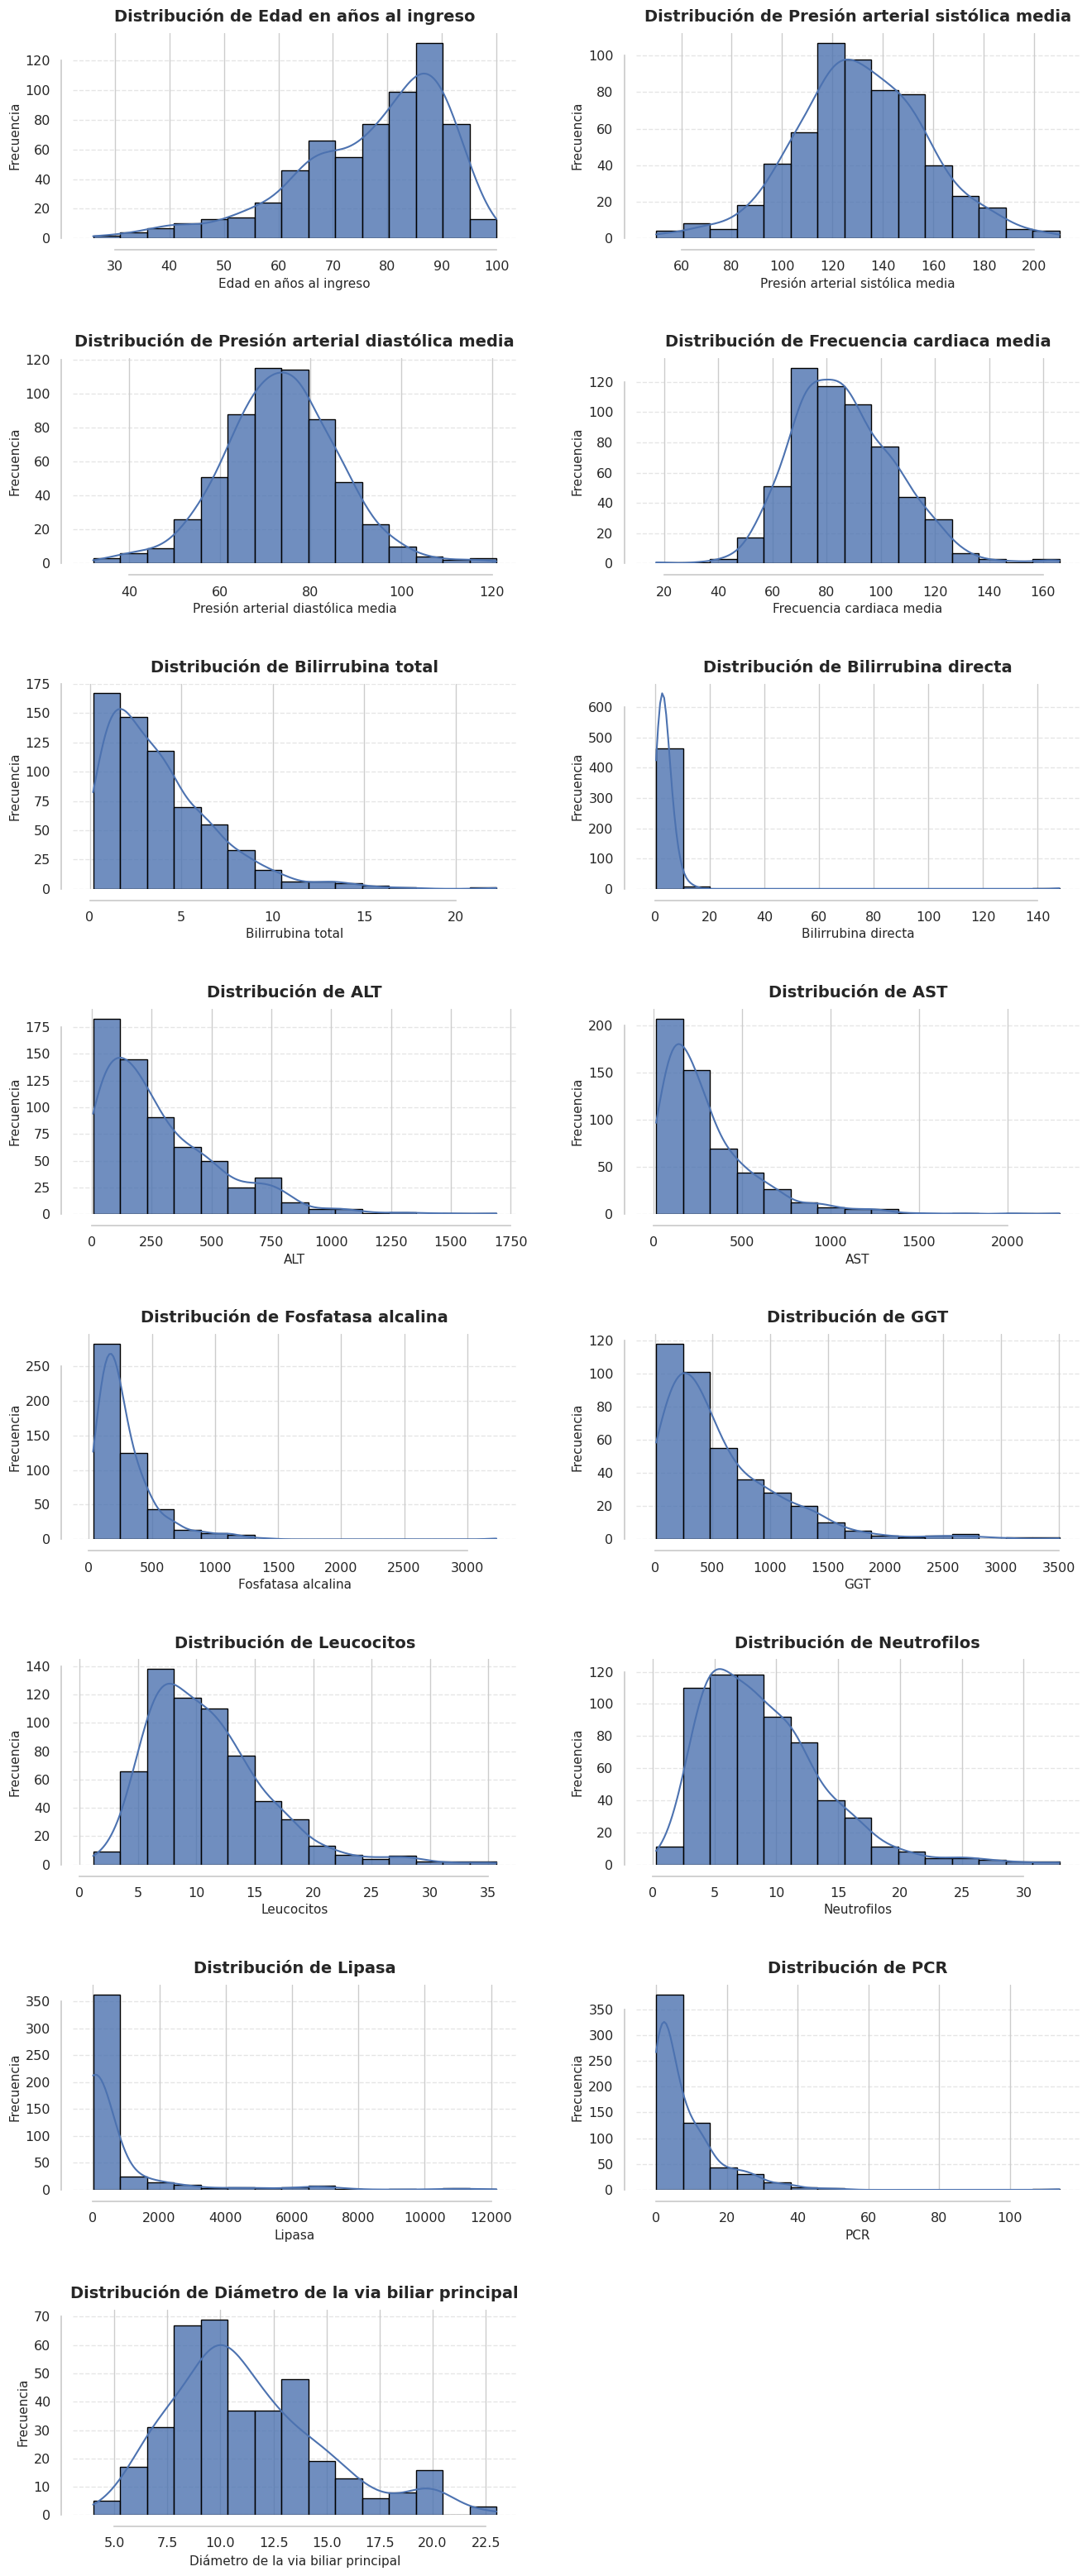

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Configuración de Estilo Global
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.05)


# 2. Configuración de Subplots
n = len(columnas_numericas)
ncols = 2
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows)) # figsize=(14, 28)

axes = axes.flatten()

# 3. Recorrer y Graficar con Estética Mejorada
for i, columna in enumerate(columnas_numericas):
    ax = axes[i] # Alias para el subplot actual

    # Crear el histograma con colores y bordes definidos
    sns.histplot(
        df[columna],
        kde=True,
        ax=ax,
        bins=15,
        color='#4c72b0', #
        edgecolor='black',
        alpha=0.8 # Transparencia
    )

    # Personalización del Título y Ejes
    ax.set_title(
        f'Distribución de {columna}',
        fontsize=14,
        fontweight='bold',
        pad=10 # Espacio entre el título y el gráfico
    )
    ax.set_xlabel(columna, fontsize=11)
    ax.set_ylabel('Frecuencia', fontsize=11)

    # Personalización de la Rejilla y Ticks
    ax.grid(axis='y', linestyle='--', alpha=0.5) # Rejilla solo en Y, tenue

    sns.despine(ax=ax, offset=10, trim=True)


# 4. Ocultar Subplots Vacíos
for j in range(len(columnas_numericas), len(axes)):
    fig.delaxes(axes[j])

# 5. Ajustes Finales y Guardado en Alta Resolución
plt.tight_layout(pad=3.0)
plt.savefig('histogramas_tfg.png', dpi=400, bbox_inches='tight')
plt.show()

Boxplots

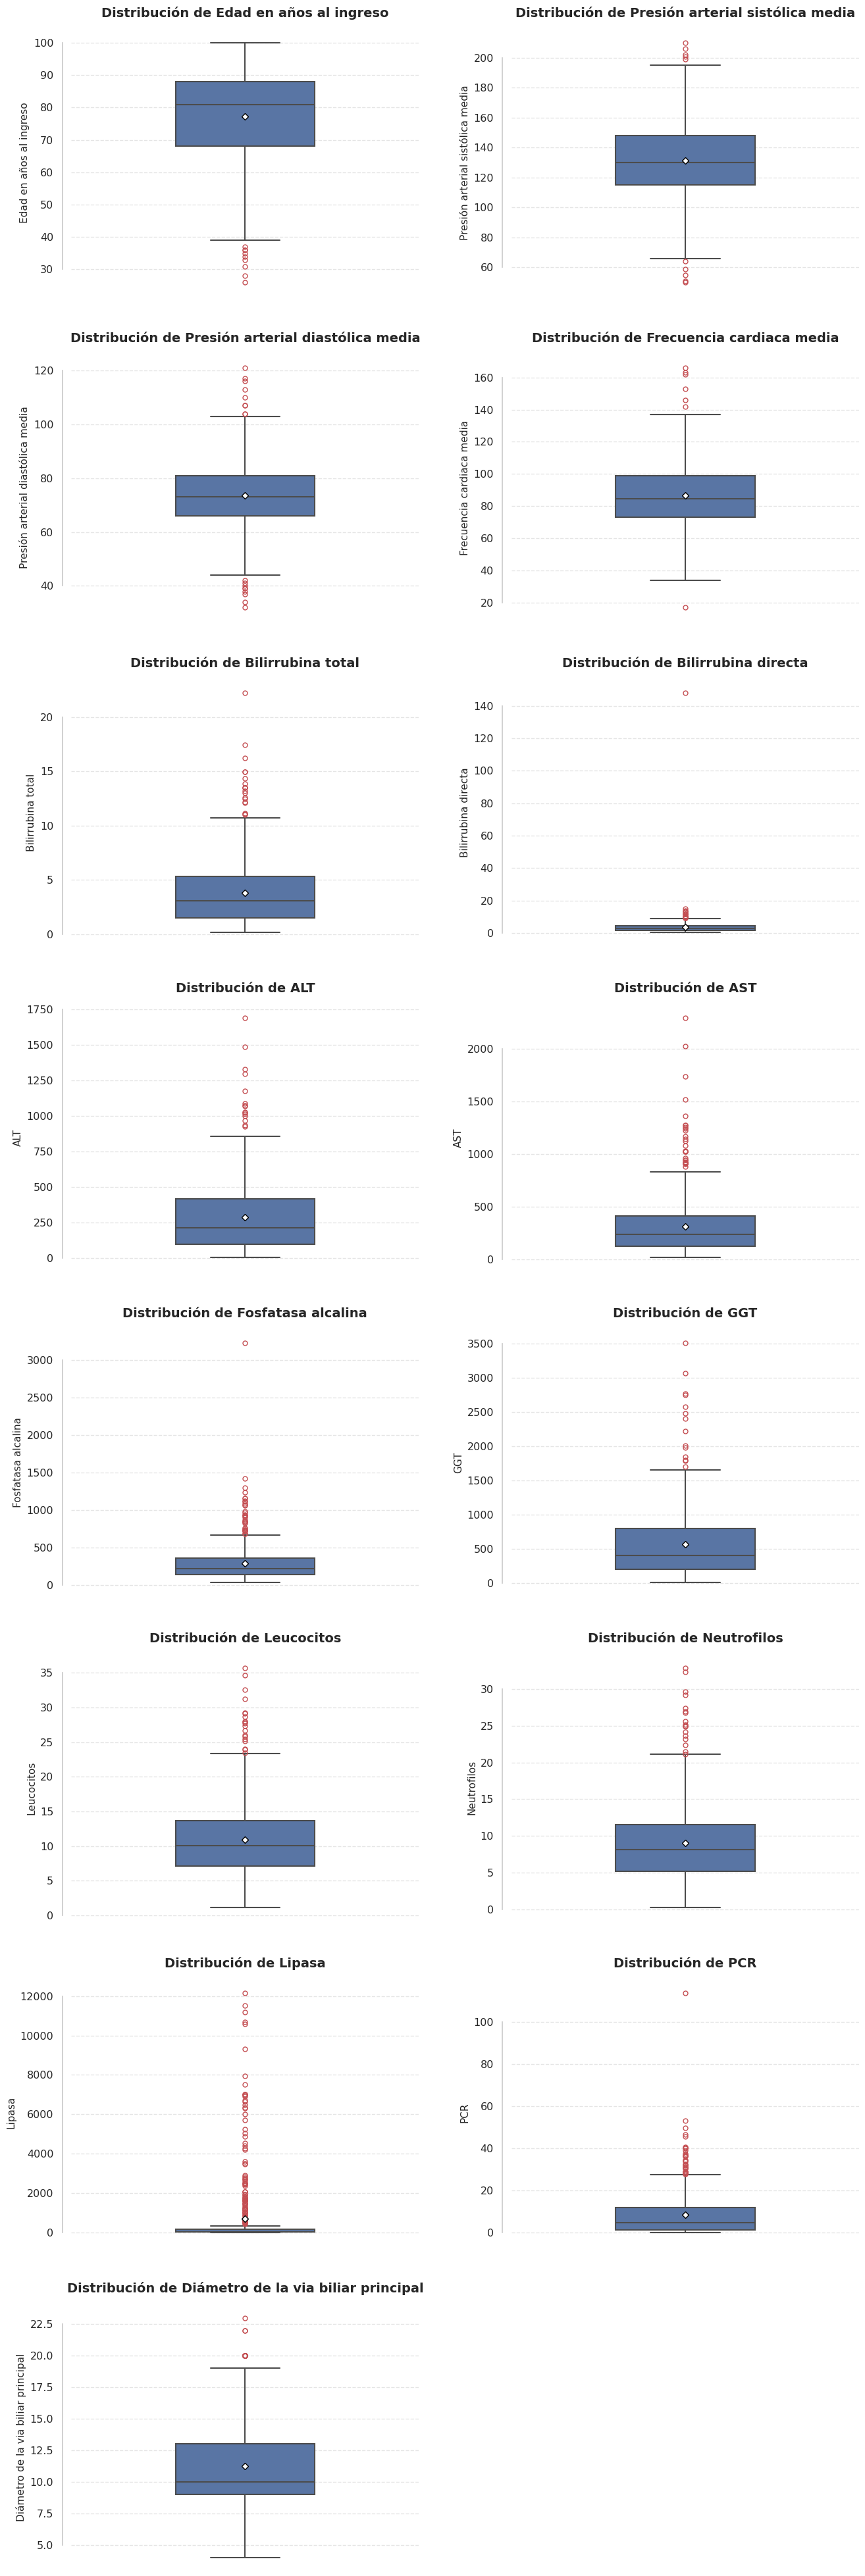

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configuración de Estilo Global
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.05)

# 2. Configuración de Subplots
n = len(columnas_numericas)
ncols = 2
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes = axes.flatten()

# 3. Recorrer y Graficar con Estética Rigurosa
for i, columna in enumerate(columnas_numericas):
    ax = axes[i]

    # Crear el Boxplot
    sns.boxplot(
        y=df[columna],
        ax=ax,
        color='#4c72b0',
        width=0.4,
        linewidth=1.5,

        # Configuración de Outliers
        fliersize=3,
        flierprops=dict(
            marker='o',
            markerfacecolor='none',
            markeredgecolor='#c44e52',
            markersize=5,
            linestyle='none'
        ),

        # Configuración de la Media
        showmeans=True,
        meanprops=dict(
            marker='D',             # Diamante
            markeredgecolor='black',
            markerfacecolor='white',
            markersize=5
        )
    )

    # Personalización del Título y Ejes
    ax.set_title(
        f'Distribución de {columna}',
        fontsize=14,
        fontweight='bold',
        pad=15
    )
    ax.set_ylabel(columna, fontsize=11)
    ax.set_xlabel('')

    # Personalización de la Rejilla y Ticks
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # "Despine" (quitar bordes)
    sns.despine(ax=ax, offset=10, trim=True, bottom=True)


# 4. Ocultar Subplots Vacíos
for j in range(len(columnas_numericas), len(axes)):
    fig.delaxes(axes[j])

# 5. Ajustes Finales y Guardado
plt.tight_layout(pad=3.0)
plt.savefig('boxplots_outliers_tfg.png', dpi=400, bbox_inches='tight')
plt.show()

Conclusiones en el word

### ***Análisis descriptivo univariante de variables categoricas***

Tablas de frecuencias

In [ ]:
tablas_frecuencia = {}

for col in columnas_categoricas:
    # Tabla de frecuencia
    tablas_frecuencia[col] = df[col].value_counts().sort_values(ascending=False).reset_index()

# Mostrar resultados
for col in columnas_categoricas:
    print(f"\nFrecuencia de {col}:")
    print(tablas_frecuencia[col].to_string(index=False))



Frecuencia de Sexo:
  Sexo  count
Hombre    334
 Mujer    305

Frecuencia de Dolor abdominal:
Dolor abdominal  count
             Si    478
             No    138

Frecuencia de Ictericia mucocutánea:
Ictericia mucocutánea  count
                   No    401
                   Si    216

Frecuencia de Temperatura > 37.8 ºC:
Temperatura > 37.8 ºC  count
                   No    495
                   Si    108

Frecuencia de Prueba de imagen:
Prueba de imagen  count
             ECO    533
 Prueba avanzada    104

Frecuencia de Colelitiasis:
Colelitiasis  count
          Si    543
          No     93

Frecuencia de Coledocolitiasis:
Coledocolitiasis  count
              No    433
              Si    204

Frecuencia de Colecistitis:
Colecistitis  count
          No    443
          Si    193

Frecuencia de Prueba confirmación de la presencia de coledocolitiasis:
Prueba confirmación de la presencia de coledocolitiasis  count
                                                   CPRE    396


Graficos de barras

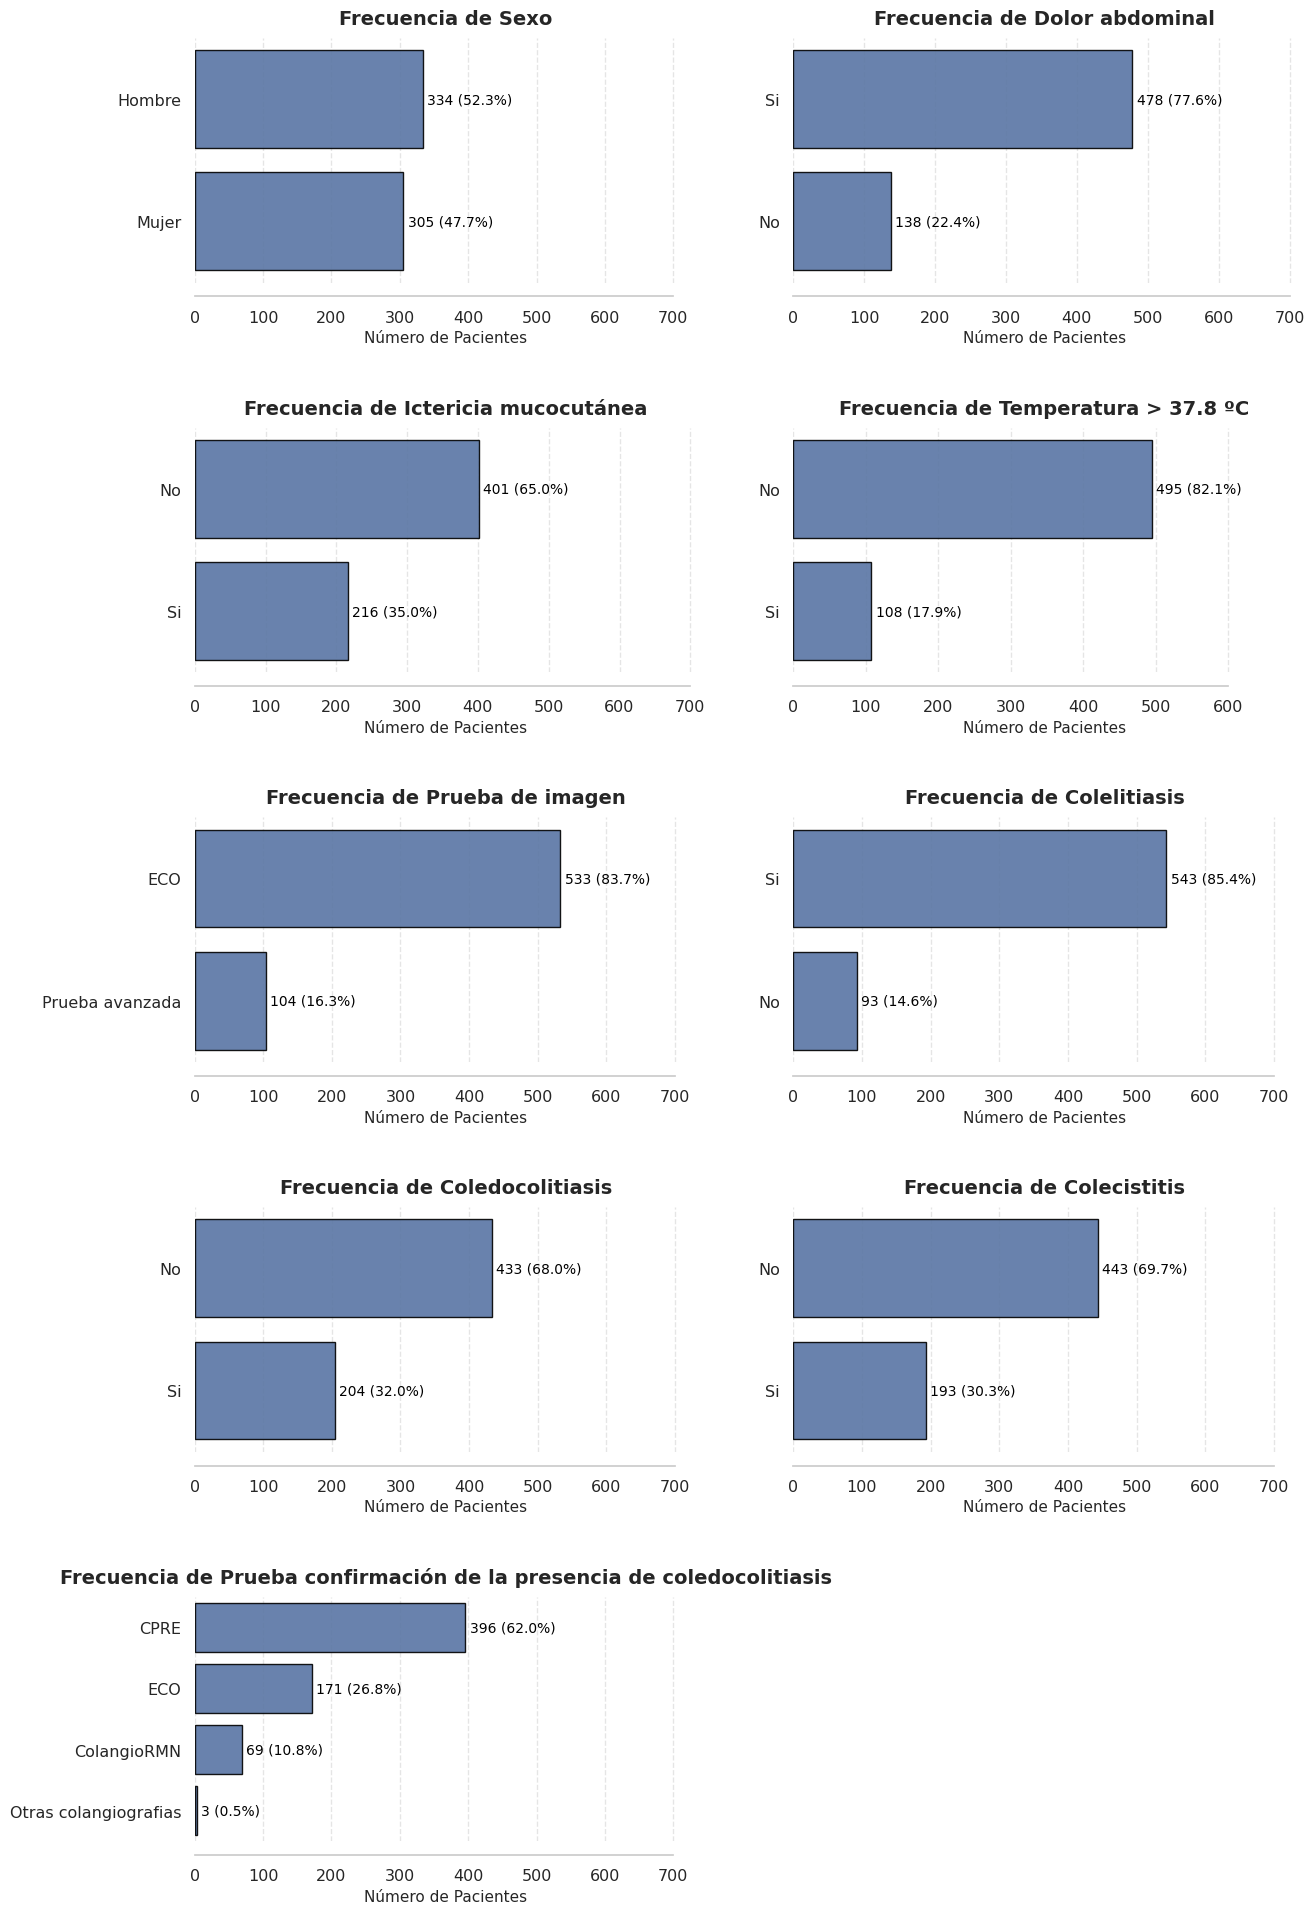

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configuración de Estilo
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.05)

# 2. Configuración de Subplots
n = len(columnas_categoricas)
ncols = 2
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

# 3. Recorrer y Graficar
for i, columna in enumerate(columnas_categoricas):
    ax = axes[i]

    # Calcular el orden
    order = df[columna].value_counts().index

    # Crear el Countplot

    sns.countplot(
        y=df[columna],
        ax=ax,
        order=order,
        color='#4c72b0',  # Mismo azul
        edgecolor='black',
        alpha=0.9
    )


    total = len(df[columna].dropna()) # Total de datos no nulos en esa variable

    for p in ax.patches:
        width = p.get_width()

        # Cálculo del porcentaje
        percentage = f'{100 * width / total:.1f}%'


        x_text = width + (total * 0.01) # Offset dinámico según la escala
        y_text = p.get_y() + p.get_height() / 2


        label_text = f'{int(width)} ({percentage})'

        ax.text(
            x_text,
            y_text,
            label_text,
            ha='left',
            va='center',
            fontsize=10,
            color='black',
            fontweight='medium'
        )
    # -----------------------------------------------------------------------

    # Personalización
    ax.set_title(
        f'Frecuencia de {columna}',
        fontsize=14,
        fontweight='bold',
        pad=10
    )
    ax.set_xlabel('Número de Pacientes', fontsize=11)
    ax.set_ylabel('')


    ax.set_xlim(right=total * 1.15)


    ax.grid(axis='x', linestyle='--', alpha=0.5)

    # Limpieza visual
    sns.despine(ax=ax, offset=10, trim=True, left=True)

# 4. Ocultar Subplots Vacíos
for j in range(len(columnas_categoricas), len(axes)):
    fig.delaxes(axes[j])

# 5. Guardado
plt.tight_layout(pad=3.0)
plt.savefig('barras_categoricas_tfg.png', dpi=400, bbox_inches='tight')
plt.show()

## ***Analisis bivariado***

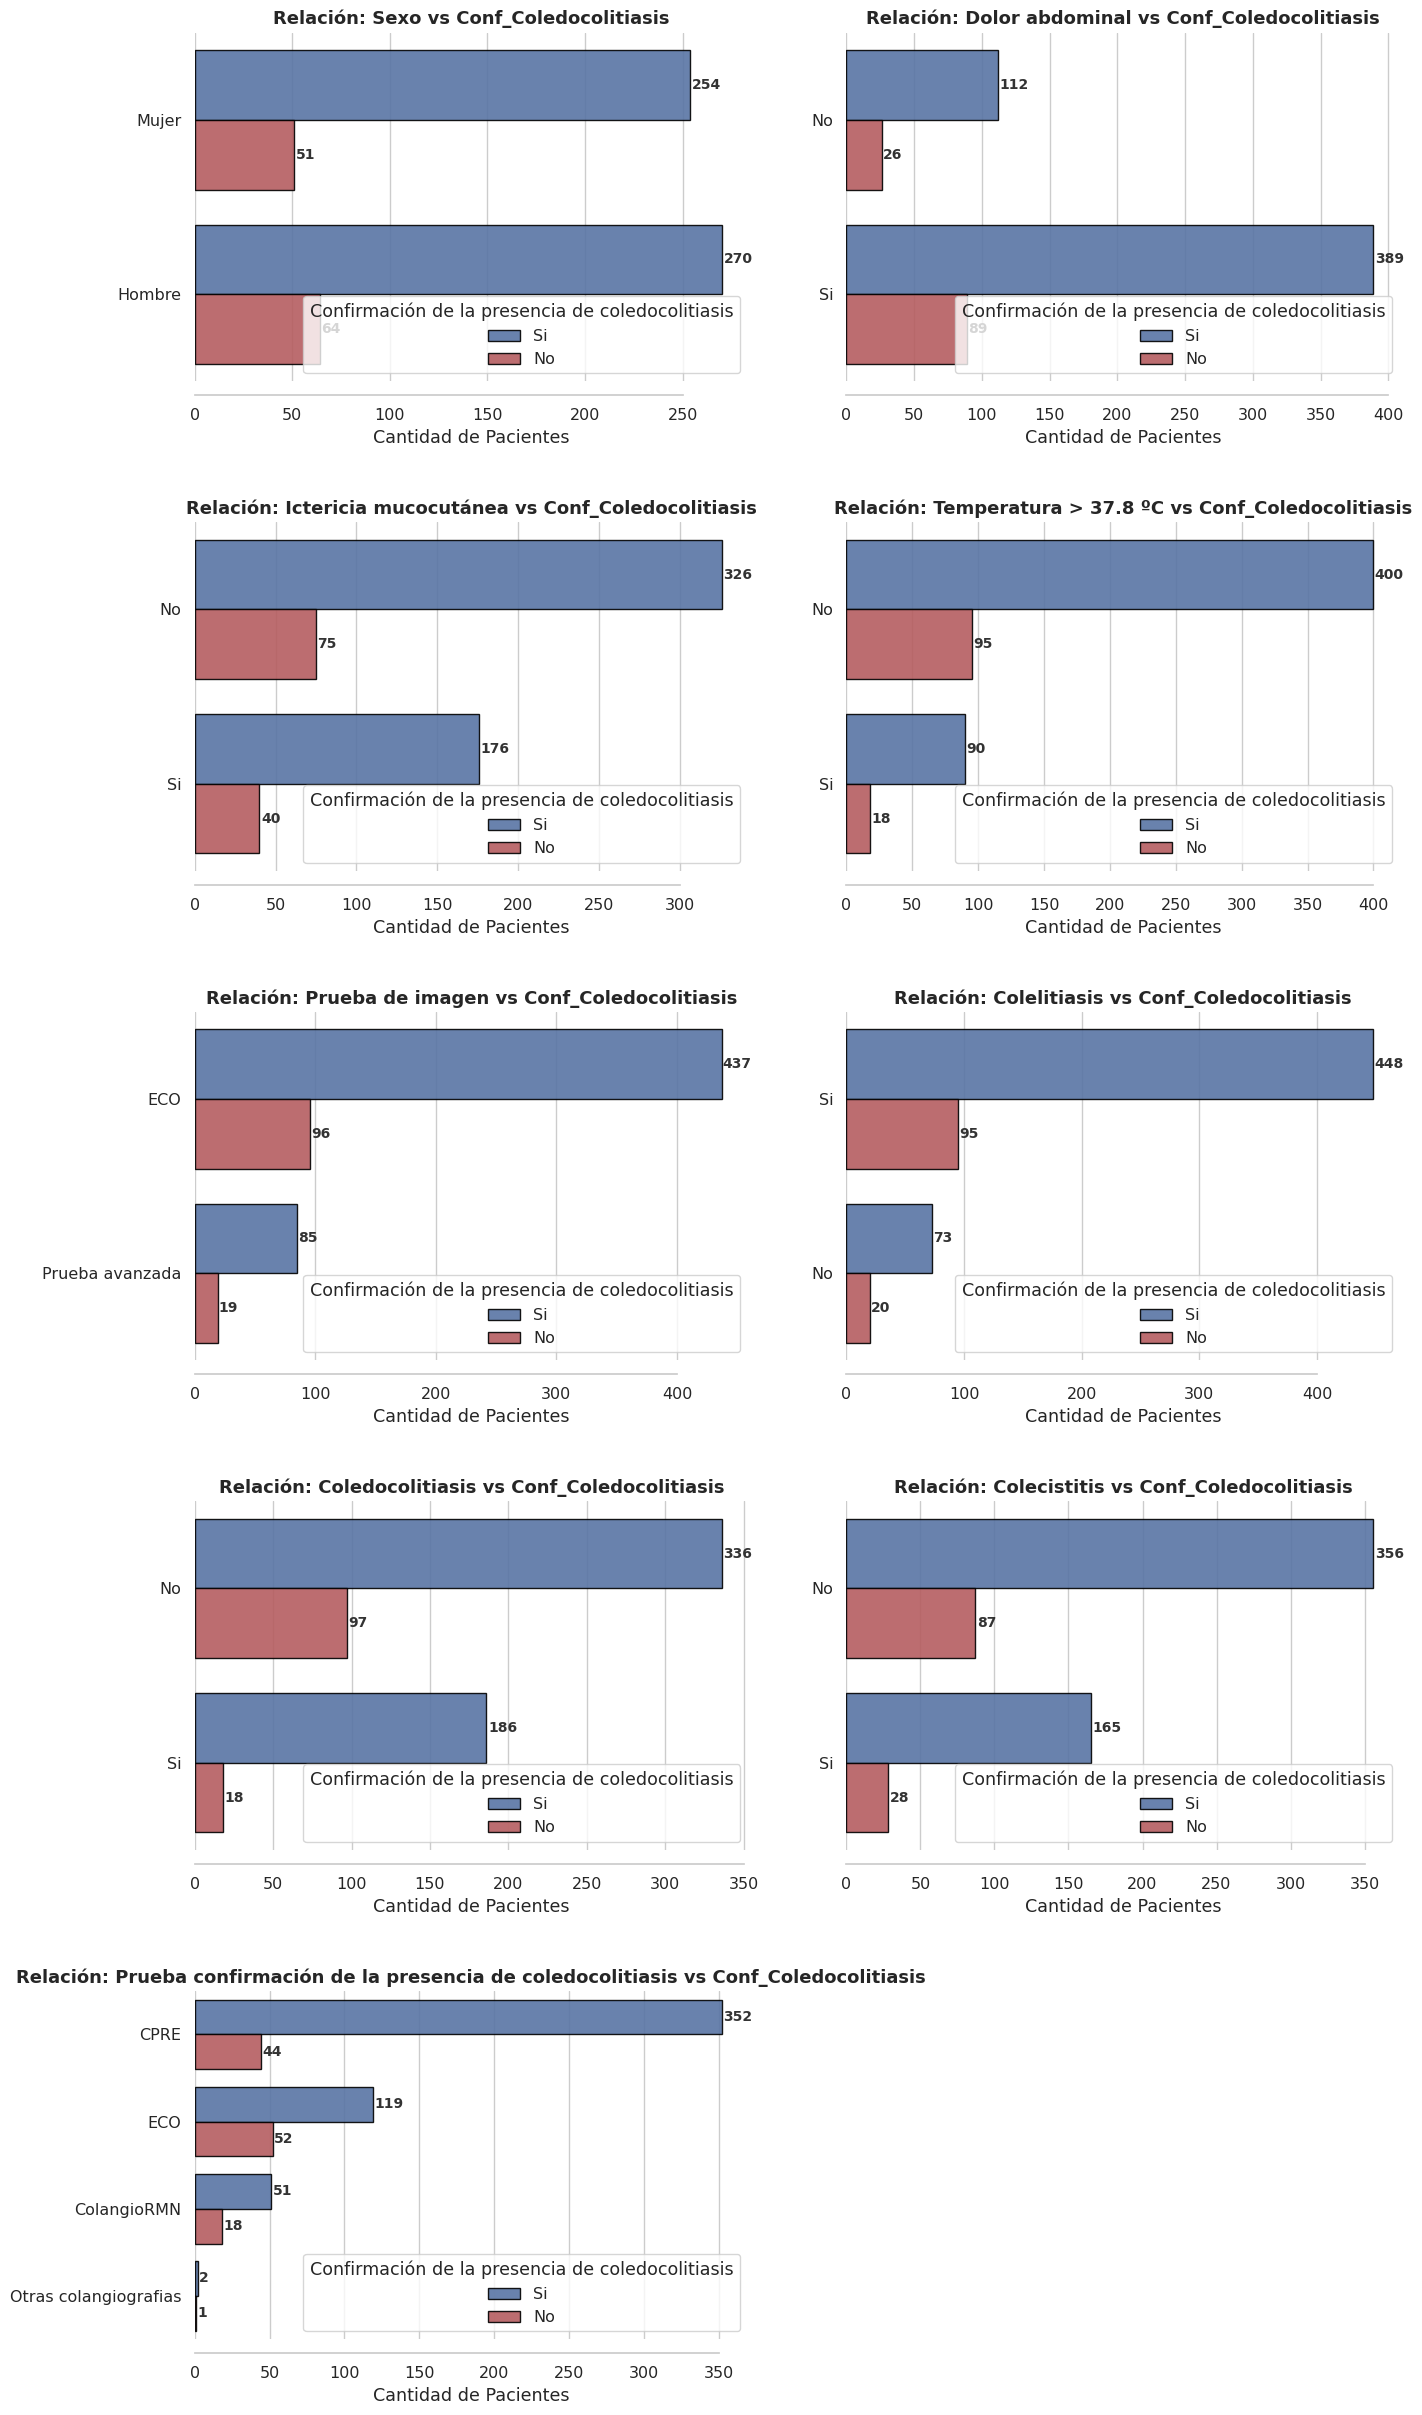

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Configuración Estética
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.05)

# 2. Preparación del Layout Dinámico
n = len(columnas_categoricas)
ncols = 2
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()

# Definir variable objetivo y colores
target = 'Confirmación de la presencia de coledocolitiasis'
colores = ["#4c72b0", "#c44e52"] # Azul (Control) y Rojo (Caso)

# 3. Bucle de Gráficos
for i, var in enumerate(columnas_categoricas):
    ax = axes[i]

    # Crear el gráfico
    sns.countplot(
        y=var,
        hue=target,
        data=df,
        ax=ax,
        palette=colores,
        edgecolor='black',
        alpha=0.9
    )

    for p in ax.patches:
        width = p.get_width()
        if np.isnan(width): width = 0 #


        if width > 0:
            x_text = width + 1 # Un poco a la derecha de la barra
            y_text = p.get_y() + p.get_height() / 2

            ax.text(
                x_text,
                y_text,
                f'{int(width)}',
                ha='left',
                va='center',
                fontsize=10,
                fontweight='bold',
                color='#333333'
            )
    # -------------------------------------------------------

    # Títulos y Etiquetas
    ax.set_title(f'Relación: {var} vs {"Conf_Coledocolitiasis"}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Cantidad de Pacientes')
    ax.set_ylabel('')

    # Leyenda limpia
    ax.legend(title=target, loc='lower right', frameon=True)

    # Limpieza de bordes
    sns.despine(ax=ax, offset=10, trim=True, left=True)

# 4. Ocultar ejes vacíos si sobran huecos
for j in range(len(columnas_categoricas), len(axes)):
    fig.delaxes(axes[j])

# 5. Ajuste final
plt.tight_layout(pad=3.0)
plt.savefig('bivariado_categoricas_tfg.png', dpi=400, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact
import statsmodels.api as sm
import numpy as np

# Lista de variables categóricas proporcionadas
columnas_categoricas = [
    'Sexo','Ictericia mucocutánea','Dolor abdominal','Temperatura > 37.8 ºC',
    'Prueba de imagen', 'Colelitiasis', 'Coledocolitiasis','Colecistitis',
    'Confirmación de la presencia de coledocolitiasis'
]

# Variable respuesta
respuesta = 'Confirmación de la presencia de coledocolitiasis'

# Función para calcular OR (odds ratio) e IC95%
def calcular_or(tabla):
    # Tabla 2x2
    (a, b), (c, d) = tabla
    or_val = (a*d) / (b*c)
    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    ci_low = np.exp(np.log(or_val) - 1.96*se)
    ci_high = np.exp(np.log(or_val) + 1.96*se)
    return or_val, ci_low, ci_high

# Bucle de análisis
resultados = []

for col in columnas_categoricas:
    if col == respuesta:
        continue  # no comparar la variable consigo misma

    tabla = pd.crosstab(df[col], df[respuesta])

    # Determinar si usar chi-cuadrado o Fisher
    if (tabla.values < 5).any():
        test = "Fisher"
        oddsratio, p = fisher_exact(tabla)
    else:
        test = "Chi-cuadrado"
        chi2, p, _, _ = chi2_contingency(tabla)
        # Para OR necesitamos tabla 2x2
        if tabla.shape == (2,2):
            oddsratio, ci_low, ci_high = calcular_or(tabla.values)
        else:
            oddsratio, ci_low, ci_high = (None, None, None)

    resultados.append({
        "Variable": col,
        "Test": test,
        "p": p,
        "OR": oddsratio if tabla.shape == (2,2) else None,
        "IC95%": (ci_low, ci_high) if tabla.shape == (2,2) else None,
        "Tabla": tabla
    })

# Mostrar resultados
for r in resultados:
    print("--------------------------------------------------")
    print(f"Variable: {r['Variable']}")
    print("Tabla de contingencia:")
    print(r["Tabla"])
    print(f"Test utilizado: {r['Test']}")
    print(f"p-valor: {r['p']:.4f}")

    if r["OR"] is not None:
        print(f"Odds Ratio: {r['OR']:.3f}")
        print(f"IC95%: {r['IC95%']}")


--------------------------------------------------
Variable: Sexo
Tabla de contingencia:
Confirmación de la presencia de coledocolitiasis  No   Si
Sexo                                                     
Hombre                                            64  270
Mujer                                             51  254
Test utilizado: Chi-cuadrado
p-valor: 0.4846
Odds Ratio: 1.181
IC95%: (np.float64(0.7867329032958346), np.float64(1.7714634119193948))
--------------------------------------------------
Variable: Ictericia mucocutánea
Tabla de contingencia:
Confirmación de la presencia de coledocolitiasis  No   Si
Ictericia mucocutánea                                    
No                                                75  326
Si                                                40  176
Test utilizado: Chi-cuadrado
p-valor: 1.0000
Odds Ratio: 1.012
IC95%: (np.float64(0.6615987754986644), np.float64(1.5488094395621568))
--------------------------------------------------
Variable: Dolor abdo

In [ ]:
import pandas as pd
from scipy.stats import fisher_exact

def prueba_fisher(df, var_analisis, var_objetivo='Confirmación de la presencia de coledocolitiasis'):
    """
    Calcula el Test Exacto de Fisher y el Odds Ratio para tablas 2x2.
    """
    print(f"--- TEST EXACTO DE FISHER: {var_analisis} vs {var_objetivo} ---")

    # 1. Crear Tabla de Contingencia
    tabla = pd.crosstab(df[var_analisis], df[var_objetivo])
    print("\n1. Tabla de Contingencia:")
    print(tabla)

    # 2. Verificar dimensiones
    if tabla.shape != (2, 2):
        print(f"\n⚠️ ERROR: La tabla es de dimensión {tabla.shape}.")
        print("   El test de Fisher en scipy solo admite tablas de 2x2 (variables binarias).")
        print("   Revisa que tus variables solo tengan 2 categorías.")
        print("-" * 60 + "\n")
        return

    # 3. Ejecutar Test de Fisher
    odds_ratio, p_value = fisher_exact(tabla, alternative='two-sided')

    print(f"\n2. Resultados:")
    print(f"   - P-valor: {p_value:.4f}")
    print(f"   - Odds Ratio (OR): {odds_ratio:.4f}")

    # 4. Interpretación Automática
    print("\n3. Interpretación:")
    if p_value < 0.05:
        print(f"   ✅ SIGNIFICATIVO. Existe una asociación entre '{var_analisis}' y '{var_objetivo}'.")
        if odds_ratio > 1:
            print(f"   -> OR > 1: La presencia de '{var_analisis}' se asocia a un MAYOR riesgo de tener {var_objetivo}.")
        else:
            print(f"   -> OR < 1: La presencia de '{var_analisis}' parece ser un factor PROTECTOR.")
    else:
        print(f"   ❌ NO SIGNIFICATIVO. No hay evidencia suficiente para afirmar asociación (p > 0.05).")

    print("-" * 60 + "\n")


variables_fisher = ['Colecistitis']

for var in variables_fisher:
    prueba_fisher(df, var, var_objetivo='Coledocolitiasis')

--- TEST EXACTO DE FISHER: Colecistitis vs Coledocolitiasis ---

1. Tabla de Contingencia:
Coledocolitiasis   No   Si
Colecistitis              
No                296  146
Si                136   57

2. Resultados:
   - P-valor: 0.4061
   - Odds Ratio (OR): 0.8497

3. Interpretación:
   ❌ NO SIGNIFICATIVO. No hay evidencia suficiente para afirmar asociación (p > 0.05).
------------------------------------------------------------



In [ ]:
from scipy.stats import shapiro

print("\n--- Test de Normalidad (Shapiro-Wilk) ---")
for col in columnas_numericas:
    stat, p = shapiro(df[col])
    print(f"\nVariable: {col}")
    print(f"  Estadístico de Shapiro-Wilk: {stat:.4f}")
    print(f"  p-valor: {p:.4f}")
    if p > 0.05:
        print("  La distribución parece normal (no se rechaza H0).")
    else:
        print("  La distribución no parece normal (se rechaza H0).")



--- Test de Normalidad (Shapiro-Wilk) ---

Variable: Edad en años al ingreso
  Estadístico de Shapiro-Wilk: 0.9239
  p-valor: 0.0000
  La distribución no parece normal (se rechaza H0).

Variable: Presión arterial sistólica media
  Estadístico de Shapiro-Wilk: nan
  p-valor: nan
  La distribución no parece normal (se rechaza H0).

Variable: Presión arterial diastólica media
  Estadístico de Shapiro-Wilk: nan
  p-valor: nan
  La distribución no parece normal (se rechaza H0).

Variable: Frecuencia cardiaca media
  Estadístico de Shapiro-Wilk: nan
  p-valor: nan
  La distribución no parece normal (se rechaza H0).

Variable: Bilirrubina total
  Estadístico de Shapiro-Wilk: nan
  p-valor: nan
  La distribución no parece normal (se rechaza H0).

Variable: Bilirrubina directa
  Estadístico de Shapiro-Wilk: nan
  p-valor: nan
  La distribución no parece normal (se rechaza H0).

Variable: ALT
  Estadístico de Shapiro-Wilk: nan
  p-valor: nan
  La distribución no parece normal (se rechaza H0).



In [ ]:
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu

respuesta = 'Coledocolitiasis'

# Variables normales
vars_normales = [
    'Presión arterial sistólica media']

# Variables no normales
vars_no_normales = [
    'Edad en años al ingreso',
    'Bilirrubina total',
    'Bilirrubina directa',
    'Presión arterial diastólica media',
    'Frecuencia cardiaca media',
    'ALT',
    'AST',
    'Fosfatasa alcalina',
    'Leucocitos',
    'Neutrofilos',
    'Lipasa',
    'PCR'
]

resultados = []

# ---- VARIABLES NORMALES: t-test ----
for col in vars_normales:
    grupo_no = df[df[respuesta] == "No"][col].dropna()
    grupo_si = df[df[respuesta] == "Si"][col].dropna()

    stat, p = ttest_ind(grupo_no, grupo_si, equal_var=False)  # Welch

    resultados.append({
        "Variable": col,
        "Test": "t-test de Student (Welch)",
        "p": p,
        "Media No": grupo_no.mean(),
        "Media Si": grupo_si.mean()
    })

# ---- VARIABLES NO NORMALES: Mann-Whitney U ----
for col in vars_no_normales:
    grupo_no = df[df[respuesta] == "No"][col].dropna()
    grupo_si = df[df[respuesta] == "Si"][col].dropna()

    stat, p = mannwhitneyu(grupo_no, grupo_si, alternative='two-sided')

    resultados.append({
        "Variable": col,
        "Test": "Mann-Whitney U",
        "p": p,
        "Mediana No": grupo_no.median(),
        "Mediana Si": grupo_si.median()
    })

# ----- Mostrar resultados -----
for r in resultados:
    print("--------------------------------------------------")
    print(f"Variable: {r['Variable']}")
    print(f"Test: {r['Test']}")
    print(f"p-valor: {r['p']:.4f}")

    if "Media No" in r:
        print(f"Media (No): {r['Media No']:.2f}")
        print(f"Media (Si): {r['Media Si']:.2f}")
    else:
        print(f"Mediana (No): {r['Mediana No']:.2f}")
        print(f"Mediana (Si): {r['Mediana Si']:.2f}")


--------------------------------------------------
Variable: Presión arterial sistólica media
Test: t-test de Student (Welch)
p-valor: 0.0683
Media (No): 127.33
Media (Si): 133.01
--------------------------------------------------
Variable: Edad en años al ingreso
Test: Mann-Whitney U
p-valor: 0.0000
Mediana (No): 76.00
Mediana (Si): 85.00
--------------------------------------------------
Variable: Bilirrubina total
Test: Mann-Whitney U
p-valor: 0.0179
Mediana (No): 2.30
Mediana (Si): 2.88
--------------------------------------------------
Variable: Bilirrubina directa
Test: Mann-Whitney U
p-valor: 0.0010
Mediana (No): 1.43
Mediana (Si): 2.07
--------------------------------------------------
Variable: Presión arterial diastólica media
Test: Mann-Whitney U
p-valor: 0.1732
Mediana (No): 75.00
Mediana (Si): 72.88
--------------------------------------------------
Variable: Frecuencia cardiaca media
Test: Mann-Whitney U
p-valor: 0.1015
Mediana (No): 89.00
Mediana (Si): 82.18
------------

In [ ]:
from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind, chi2_contingency, fisher_exact
import statsmodels.stats.multitest as smm
import numpy as np
import pandas as pd

# Variable objetivo
target = 'Confirmación de la presencia de coledocolitiasis'

# Separar grupos
cdl_neg = df[df[target] == 'No']
cdl_pos = df[df[target] == 'Si']

# ─────────────────────────────────────────────────────────────
# TABLA 1 — VARIABLES CUALITATIVAS vs CDL
# ─────────────────────────────────────────────────────────────

resultados_cat = []

# Excluir la variable objetivo y la de confirmación
cat_filtradas = [c for c in columnas_categoricas
                 if c not in [target, 'Prueba confirmación de la presencia de coledocolitiasis']]

for col in cat_filtradas:
    tabla = pd.crosstab(df[col], df[target])

    # Elegir test según frecuencias esperadas
    chi2, p, dof, expected = chi2_contingency(tabla)
    test_usado = 'Chi-cuadrado'
    if (expected < 5).any():
        _, p = fisher_exact(tabla)
        test_usado = 'Fisher'

    # OR e IC 95% solo para variables dicotómicas
    or_val, ic_low, ic_high = None, None, None
    categorias = df[col].dropna().unique()
    if len(tabla) == 2:
        try:
            a = tabla.iloc[0, 1]  # cat1 & CDL+
            b = tabla.iloc[0, 0]  # cat1 & CDL-
            c = tabla.iloc[1, 1]  # cat2 & CDL+
            d = tabla.iloc[1, 0]  # cat2 & CDL-
            or_val = (a * d) / (b * c)
            se = np.sqrt(1/a + 1/b + 1/c + 1/d)
            ic_low = np.exp(np.log(or_val) - 1.96 * se)
            ic_high = np.exp(np.log(or_val) + 1.96 * se)
        except:
            pass

    # Frecuencias por grupo
    for grupo, label in [(cdl_neg, 'CDL-'), (cdl_pos, 'CDL+')]:
        counts = grupo[col].value_counts()

    n_neg = cdl_neg[col].notna().sum()
    n_pos = cdl_pos[col].notna().sum()

    # Categoría de referencia (la más frecuente)
    cat_ref = df[col].value_counts().index[0]
    n_neg_ref = (cdl_neg[col] == cat_ref).sum()
    n_pos_ref = (cdl_pos[col] == cat_ref).sum()
    pct_neg = f"{n_neg_ref/n_neg*100:.1f}"
    pct_pos = f"{n_pos_ref/n_pos*100:.1f}"

    or_str = f"{or_val:.2f} ({ic_low:.2f}–{ic_high:.2f})" if or_val else "—"
    sig = "**" if p < 0.05 else ""

    resultados_cat.append({
        'Variable': col,
        'Categoría ref.': cat_ref,
        f'CDL– N (%)': f"{n_neg_ref} ({pct_neg}%)",
        f'CDL+ N (%)': f"{n_pos_ref} ({pct_pos}%)",
        'Test': test_usado,
        'p-valor': f"{sig}{p:.3f}{sig}",
        'OR (IC 95%)': or_str
    })

tabla_cat = pd.DataFrame(resultados_cat)
print("=" * 80)
print("TABLA 1 — VARIABLES CUALITATIVAS vs COLEDOCOLITIASIS")
print("=" * 80)
print(tabla_cat.to_string(index=False))


# ─────────────────────────────────────────────────────────────
# TABLA 2 — VARIABLES CUANTITATIVAS vs CDL
# ─────────────────────────────────────────────────────────────

resultados_num = []

for col in columnas_numericas:

    grupo_neg = cdl_neg[col].dropna()
    grupo_pos = cdl_pos[col].dropna()

    # Test de normalidad (Shapiro-Wilk)
    _, p_norm_neg = stats.shapiro(grupo_neg) if len(grupo_neg) <= 5000 else (None, 0)
    _, p_norm_pos = stats.shapiro(grupo_pos) if len(grupo_pos) <= 5000 else (None, 0)
    es_normal = (p_norm_neg > 0.05) and (p_norm_pos > 0.05)

    # Test según normalidad
    if es_normal:
        stat, p = ttest_ind(grupo_neg, grupo_pos, equal_var=False)
        test_usado = 't-Student'
        res_neg = f"{grupo_neg.mean():.1f} ± {grupo_neg.std():.1f}"
        res_pos = f"{grupo_pos.mean():.1f} ± {grupo_pos.std():.1f}"
        metrica = 'Media ± DE'
    else:
        stat, p = mannwhitneyu(grupo_neg, grupo_pos, alternative='two-sided')
        test_usado = 'Mann-Whitney'
        q25_neg, med_neg, q75_neg = grupo_neg.quantile([0.25, 0.5, 0.75])
        q25_pos, med_pos, q75_pos = grupo_pos.quantile([0.25, 0.5, 0.75])
        res_neg = f"{med_neg:.2f} ({q25_neg:.2f}–{q75_neg:.2f})"
        res_pos = f"{med_pos:.2f} ({q25_pos:.2f}–{q75_pos:.2f})"
        metrica = 'Mediana (IQR)'

    sig = "**" if p < 0.05 else ""

    resultados_num.append({
        'Variable': col,
        'Métrica': metrica,
        'CDL– ' + metrica: res_neg,
        'CDL+ ' + metrica: res_pos,
        'Test': test_usado,
        'p-valor': f"{sig}{p:.3f}{sig}"
    })

tabla_num = pd.DataFrame(resultados_num)
print("\n")
print("=" * 80)
print("TABLA 2 — VARIABLES CUANTITATIVAS vs COLEDOCOLITIASIS")
print("=" * 80)
print(tabla_num.to_string(index=False))


# ─────────────────────────────────────────────────────────────
# EXPORTAR A EXCEL
# ─────────────────────────────────────────────────────────────

with pd.ExcelWriter('bivariado_tfg.xlsx') as writer:
    tabla_cat.to_excel(writer, sheet_name='Cualitativas vs CDL', index=False)
    tabla_num.to_excel(writer, sheet_name='Cuantitativas vs CDL', index=False)

print("\n✅ Tablas exportadas a 'bivariado_tfg.xlsx'")

TABLA 1 — VARIABLES CUALITATIVAS vs COLEDOCOLITIASIS
             Variable Categoría ref. CDL– N (%)  CDL+ N (%)         Test   p-valor      OR (IC 95%)
                 Sexo         Hombre 64 (55.7%) 270 (51.5%) Chi-cuadrado     0.485 0.85 (0.56–1.27)
      Dolor abdominal             Si 89 (77.4%) 389 (77.6%) Chi-cuadrado     1.000 0.99 (0.61–1.60)
Ictericia mucocutánea             No 75 (65.2%) 326 (64.9%) Chi-cuadrado     1.000 0.99 (0.65–1.51)
Temperatura > 37.8 ºC             No 95 (84.1%) 400 (81.6%) Chi-cuadrado     0.636 0.84 (0.48–1.46)
     Prueba de imagen            ECO 96 (83.5%) 437 (83.7%) Chi-cuadrado     1.000 1.02 (0.59–1.75)
         Colelitiasis             Si 95 (82.6%) 448 (86.0%) Chi-cuadrado     0.434 0.77 (0.45–1.33)
     Coledocolitiasis             No 97 (84.3%) 336 (64.4%) Chi-cuadrado **0.000** 0.34 (0.20–0.57)
         Colecistitis             No 87 (75.7%) 356 (68.3%) Chi-cuadrado     0.152 0.69 (0.44–1.10)


TABLA 2 — VARIABLES CUANTITATIVAS vs COLEDOCO

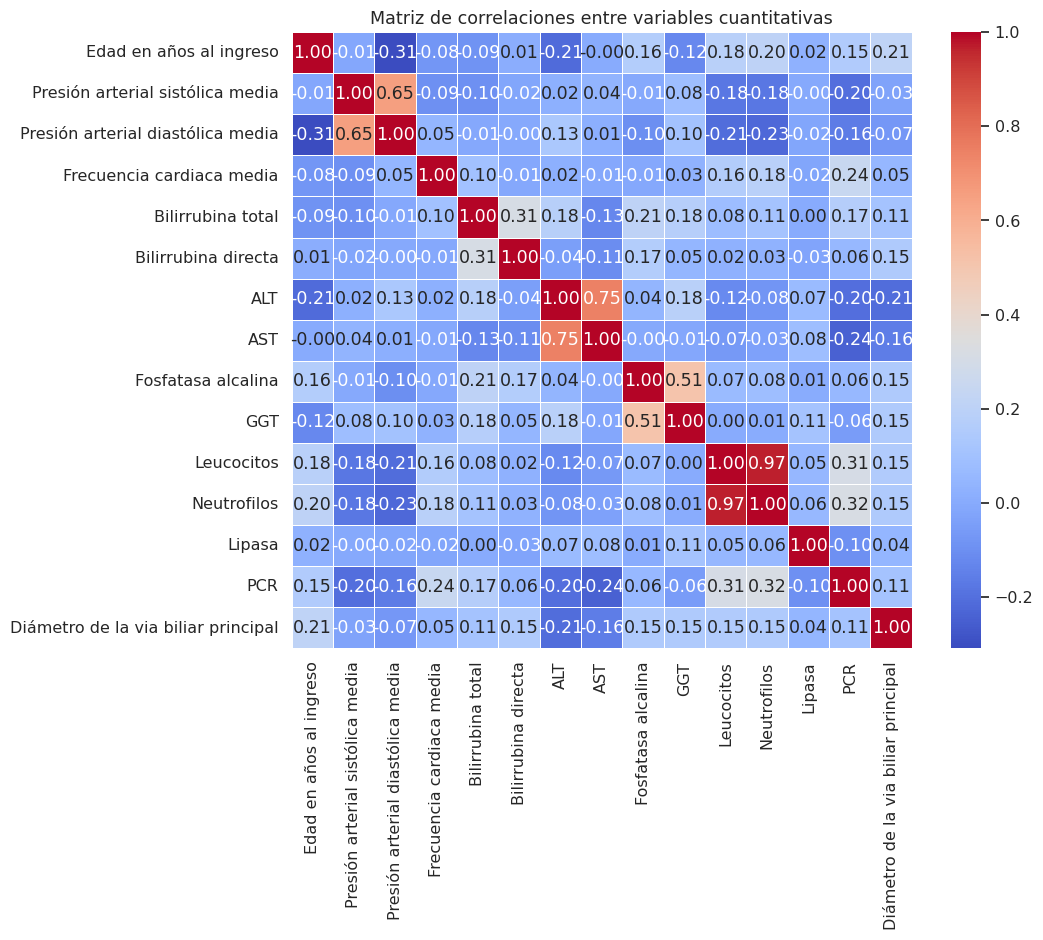

In [ ]:
# Calcular la matriz de correlaciones para las variables cuantitativas
correlation_matrix = df[columnas_numericas].corr()

# Crear heatmap para visualizar las correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlaciones entre variables cuantitativas")
plt.show()
